# Машинное обучение, ФКН ВШЭ

## Практическое задание 3.2  Продвинутая генерация признаков

### **Введение**

В этой части ноутбука задания посложнее дефолтного фит трансформа. Максимальная оценка за оба — 8 баллов, остальное вы можете получить, если примете участие в соревновании, и всего можете выбить аж 13 из 10. Тут ожидается больше самостоятельности, как от (почти) полноценной рабочей единицы:
- Вы **сами** решаете, что <font color="#cb9255">**хотите**</font> делать. Пункты можно делать частично, можно скипать или сделать часть, **максимум баллов ограничен двумя**. **Посмотрите на все из них**, прежде чем приступать
- Вы **сами** чистите данные, если чуете в них подвох (теперь они далеко не такие няшные)
- Вы **сами** <font color="#f68c9d">**обосновываете**</font> (в голове, если не указано явно), могут они вам вообще помочь или нет (часть пунктов явно сильнее других)

Все прочие пожелания по тому, как строить графики, на чём фиттить, а на чём предиктить, сохраняются, будьте внимательны. Во всех пунктах с 📈 нужно добиться хотя бы минимального улучшения, относительно бейзлайна (того, что вышло в части **base**) чтобы получить балл (даже если улучшение на 0.005)

Ещё раз обратите внимание, что **максимум за advanced часть — 2 балла**, делать всё не нужно, только самое приятное. Мы в вас верим!

### **Часть 5. Агрегации** (1.75 балла) <img align="center" src="https://static.wikia.nocookie.net/dota2_gamepedia/images/4/4a/Techies_emoticon.gif/revision/latest?cb=20180504014918">

В которой студент начинает ведать

#### 📈 **Задание 5.1. Статистики матча** (0.75 балла)

Есть у нас в данных большой кусок про advantage — преимущество команды сил Света с точностью до минуты, по золоту и опыту, всё так же **в пределах 15 минут**. Лежат они в `dota_adv.csv`. Чем больше число, тем больше шанс на победу — всё просто. Только график, как правило, не линеен.

С ними в очередной раз есть *нюансы* — необходимо разобраться, как они там лежат, и всё ли там в порядке со значениями, но это меньшая из проблем. А также нарисовать парочку advantage, чтобы было понимание, как они себя ведут

Shape: (767822, 3)
Колонки: ['match_id', 'radiant_gold_adv', 'radiant_exp_adv']

Первые 3 строки:
   match_id                                   radiant_gold_adv  \
0    526846  [   0  159  452 1904 2100 3290 3290 3290 3290 ...   
1    511496  [   0 -151 -141   12 -165 -151 -151    4  377 ...   
2     90272                                                 []   

                                     radiant_exp_adv  
0  [   0   68  658 1397 1435 2118 2118 1923 1923 ...  
1  [   0    1 -136  243 -270   -8   -8 -169 -169 ...  
2                                                 []  

Типы данных:
match_id             int64
radiant_gold_adv    object
radiant_exp_adv     object
dtype: object


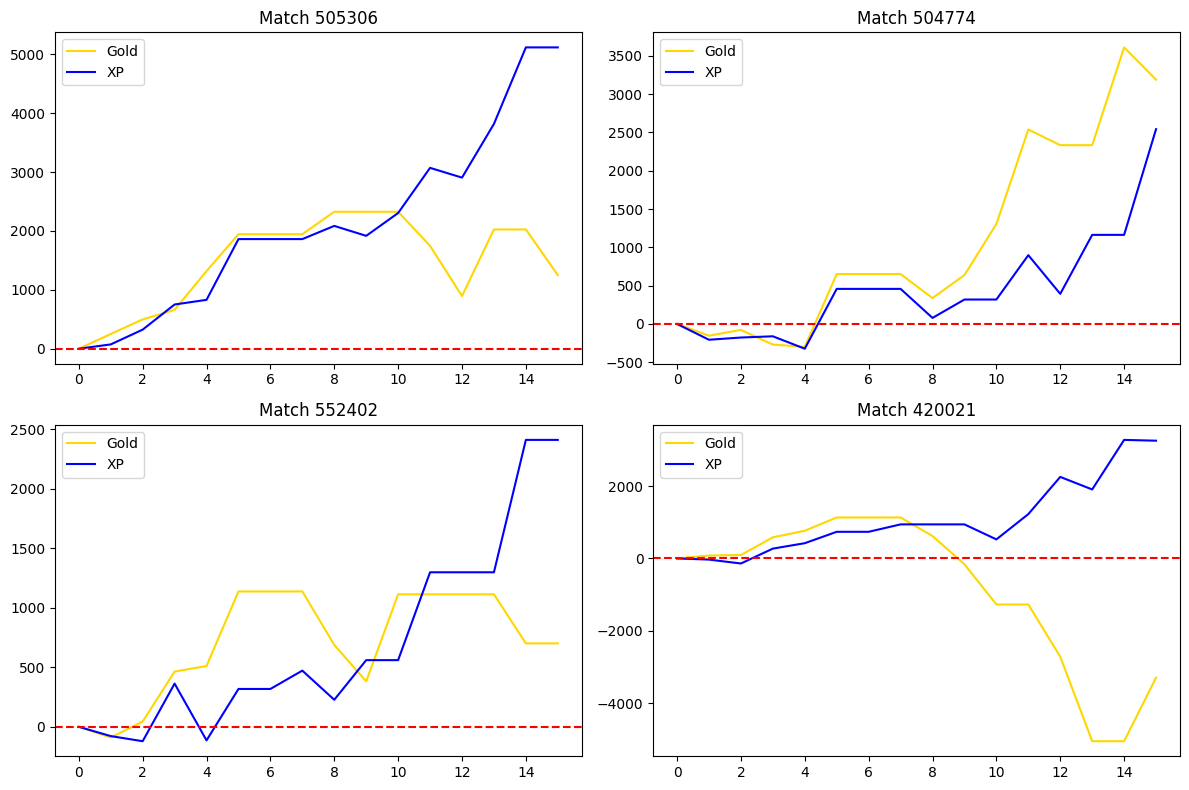

In [2]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
import pandas as pd
import matplotlib.pyplot as plt

adv_df = pd.read_csv('dota_adv.csv')
print(f"Shape: {adv_df.shape}")
print(f"Колонки: {list(adv_df.columns)}")
print(f"\nПервые 3 строки:")
print(adv_df.head(3))
print(f"\nТипы данных:")
print(adv_df.dtypes)

def parse_adv(s):
    try:
        clean_s = s.replace('[', '').replace(']', '')
        return [float(x) for x in clean_s.split()]
    except:
        return []

sample = adv_df[adv_df['radiant_gold_adv'].str.len() > 10].sample(4, random_state=42)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (_, row) in enumerate(sample.iterrows()):
    gold = parse_adv(row['radiant_gold_adv'])
    xp = parse_adv(row['radiant_exp_adv'])

    axes[i].plot(gold, label='Gold', color='gold')
    axes[i].plot(xp, label='XP', color='blue')
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f"Match {row['match_id']}")
    axes[i].legend()

plt.tight_layout()
plt.show()

Для начала возьмём простые агрегации. Можете взять те, что вам знакомы (статистики - среднее, стд и др.), можете взять фан факты в вашей любимой библиотеке для данных, например [тут](https://pandas.pydata.org/docs/user_guide/groupby.html#aggregation) или [тут](https://docs.pola.rs/api/python/stable/reference/expressions/aggregation.html).

Задание:
- взять 4 статистики из библиотеки, применить к обеим колонкам `_adv`, <font color="#f68c9d">**обдумать**</font>, почему именно они
- одну из статистику выше разбить по командам, и точно так же примените к колонкам (получится что-то типа `agg_xp` -> `agg_dire_xp`, `agg_radiant_xp`)

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Тут мы встаём на скользкую дорожку переобучения. Агрегаций можно сделать **очень** много. Добавьте их все, и ваша модель превратится в тыкву. Удобнее будет сразу бить их на группы, например `features_last`, `features_q25`, `features_kurtosis_dire_10min+` и так далее, в зависимости от степени упоротости

C другой стороны, агрегации это самая сильная группа фичей, и для десяточки лучше целиться именно в них

</div>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какие агрегации берём?

**Ответ:** Выбрал 4 статистики для каждого графика advantage (gold и xp):

- mean (среднее) — показывает, кто доминировал в среднем за 15 минут

- std (стандартное отклонение) — показывает волатильность игры ("качели")

- last (последнее значение) — advantage на 15-й минуте, самый актуальный
показатель

- max (максимум) — пиковое преимущество команды

</div>

Обучите модель по агрегациям (одной группе или нескольким) + предыдущим фичам. Чтобы получить фулл балл, придётся показать, что хотя бы минимальный импрув есть, относительно бейзлайна

In [3]:
#Все необходимое для работы модели, ибо весь код с датой остался в другом ноутбуке, придется запариться
import numpy as np
from scipy.sparse import load_npz, hstack
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

train_df_ordered = pd.read_csv('train_df_ordered.csv')
valid_df_ordered = pd.read_csv('valid_df_ordered.csv')
matches_test = pd.read_csv('matches_test_clean.csv')

train_heroes = load_npz('train_heroes.npz')
valid_heroes = load_npz('valid_heroes.npz')
test_heroes = load_npz('test_heroes.npz')

y_train_heroes = np.load('y_train_heroes.npy')
y_valid_heroes = np.load('y_valid_heroes.npy')

train_match_ids = np.load('train_match_ids.npy')
valid_match_ids = np.load('valid_match_ids.npy')
test_match_ids = np.load('test_match_ids.npy')

print(f"Train: {train_heroes.shape}")
print(f"Valid: {valid_heroes.shape}")
print(f"Test: {test_heroes.shape}")

Train: (510558, 113)
Valid: (129472, 113)
Test: (59748, 113)


In [4]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
def parse_and_stats(s):
    try:
        clean = s.replace('[', '').replace(']', '')
        arr = np.array([float(x) for x in clean.split()])
        if len(arr) == 0:
            return 0, 0, 0, 0
        return np.mean(arr), np.std(arr), arr[-1], np.max(arr)
    except:
        return 0, 0, 0, 0

gold_stats = adv_df['radiant_gold_adv'].apply(parse_and_stats)
adv_features = pd.DataFrame(gold_stats.tolist(), columns=['gold_mean', 'gold_std', 'gold_last', 'gold_max'])

xp_stats = adv_df['radiant_exp_adv'].apply(parse_and_stats)
xp_df = pd.DataFrame(xp_stats.tolist(), columns=['xp_mean', 'xp_std', 'xp_last', 'xp_max'])

adv_features = pd.concat([adv_features, xp_df], axis=1)
adv_features['match_id'] = adv_df['match_id'].values

adv_features['gold_last_radiant'] = adv_features['gold_last'].clip(lower=0)
adv_features['gold_last_dire'] = adv_features['gold_last'].clip(upper=0)
adv_features['xp_last_radiant'] = adv_features['xp_last'].clip(lower=0)
adv_features['xp_last_dire'] = adv_features['xp_last'].clip(upper=0)

print(f"Размер {adv_features.shape}")
print(adv_features.head())

Размер (767822, 13)
   gold_mean     gold_std  gold_last  gold_max   xp_mean       xp_std  \
0   2887.500  1559.052797     5342.0    5342.0  2262.250  1401.628406   
1    933.875  1342.763702     3698.0    3698.0   191.625   385.377717   
2      0.000     0.000000        0.0       0.0     0.000     0.000000   
3      0.000     0.000000        0.0       0.0     0.000     0.000000   
4      0.000     0.000000        0.0       0.0     0.000     0.000000   

   xp_last  xp_max  match_id  gold_last_radiant  gold_last_dire  \
0   3311.0  4661.0    526846             5342.0             0.0   
1    201.0   931.0    511496             3698.0             0.0   
2      0.0     0.0     90272                0.0             0.0   
3      0.0     0.0    153647                0.0             0.0   
4      0.0     0.0    694826                0.0             0.0   

   xp_last_radiant  xp_last_dire  
0           3311.0           0.0  
1            201.0           0.0  
2              0.0           0.0 

In [5]:
train_with_adv = train_df_ordered.merge(adv_features, on='match_id', how='left')
valid_with_adv = valid_df_ordered.merge(adv_features, on='match_id', how='left')

adv_cols = [col for col in adv_features.columns if col != 'match_id']

train_with_adv[adv_cols] = train_with_adv[adv_cols].fillna(0)
valid_with_adv[adv_cols] = valid_with_adv[adv_cols].fillna(0)

previous_features = ['region_encoded', 'mmr_sqrt', 'mmr_missing']
all_features = previous_features + adv_cols

X_train_dense = train_with_adv[all_features].values
X_valid_dense = valid_with_adv[all_features].values

X_train_final = hstack([X_train_dense, train_heroes])
X_valid_final = hstack([X_valid_dense, valid_heroes])

print(f"Размер X_train: {X_train_final.shape}")

model_adv = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_adv.fit(X_train_final, y_train_heroes)

pred_adv = model_adv.predict_proba(X_valid_final)[:, 1]
gini_adv = gini(y_valid_heroes, pred_adv)

print(f"\nGini (baseline):      0.3050")
print(f"Gini (+ агрегации):   {gini_adv:.4f}")

Размер X_train: (510558, 128)

Gini (baseline):      0.3050
Gini (+ агрегации):   0.3836


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


прирост джини хороший, почти +0.08, есть варниниг, предлагают увеличить количество итераций (но тогда алгритм вообще долго работать будет) или изменить данные, но в нашем случае стандартизация съест много памяти, да и данные не подходят для стандартизации - для голд и хп важен масштаб и данным по героям это может навредить, а другие солверы хуже (экспериментальным путем в прошлом ноутбуке пришел к этому выводу)

#### 📈 **Задание 5.2. Тренд** (0.5 балла)

Каждый уважающий себя лудоман знает, что 99% процентов игроков останавливается ровно перед тем, как сорвать джекпот. Так и здесь — если команда с треском проигрывает в первые 15 минут матча, возможно это признак камбека в следующие 50, как знать? Попробуем собрать агрегацию похитрее — она будет обозначать тренд, который есть в графиках преимущества, и если пословица верна, наша модель уловит эту зависимость.

<span style="color:grey"><font size="1">Администрация курса МО-1 категорически против азартных игр, пример приводится сугубо в образовательных целях.</font></span>

<div style="border-left: 5px solid #f68c9d; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** для чего нам вообще тренд? Полезная ли это агрегация?

**Ответ:** Тренд показывает динамику игры - команда набирает силу или начинает проигрывать. Даже если например счет равный, то тренд покажет, кто сейчас играет лучше. Команда с положительным трендом скорее всего продолжит доминировать. Это полезная агригация, т к она добавляет информацию о динамике игры

</div>

Агрегировать можно и вещи несколько более прикольные, чем те, что есть в основном функционале. Делать это мы будем, как вы наверняка догадались, трансформером, ну а чем же ещё. Что он умеет?

1. Принимает на вход функцию колонку и <font color="#cb9255">**параметры**</font> на ваш вкус, как минимум `method`, метод расчёта `slope`
2. Выделяет коэффициент наклона (`slope`, он же $\alpha$) при помощи одного из методов:
   - `'delta'`: разность первого и последнего значений $|x_{\max} - x_{\min}|$
   - `'OLS'`: линейная регрессия, обученная методом МНК $(X^TX)^{-1}X^Ty$
   - альтернативный метод, порождённый вашей бурной фантазией
3. Считает `r2` и `intercept` для одного advantage (если что это тоже могут быть наши фичи!)

In [ ]:
# from typing import Iterable

# class TrendTransformer:

#     def __init__(self, columns: Iterable[str]):
#         self.columns = columns

#     def fit(self, X, y=None):
#         pass

#     def transform(self, X, y=None):
#         # ヾ(⌐■_■)ノ♪ your code here
#         raise Exception("transform method not implemented")

Реализуйте трансформер. Критерий успеха, вновь, качество — фича должна помочь, хотя бы на долю пункта

In [6]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
from typing import Iterable

class TrendTransformer:

    def __init__(self, columns: Iterable[str], method='delta'):
        self.columns = columns
        self.method = method

    def fit(self, X, y=None):
        return self

    def _parse(self, s):
        try:
            clean = s.replace('[', '').replace(']', '')
            return np.array([float(x) for x in clean.split()])
        except:
            return np.array([])

    def _calc_trend(self, arr):
        if len(arr) < 2:
            return 0, 0, 0

        if self.method == 'delta':
            slope = arr[-1] - arr[0]
            return slope, 0, arr[0]

        elif self.method == 'OLS':
            x = np.arange(len(arr))
            y = arr
            X = np.column_stack([x, np.ones(len(x))])
            XtX_inv = np.linalg.inv(X.T @ X)
            beta = XtX_inv @ X.T @ y
            slope = beta[0]
            intercept = beta[1]
            y_pred = X @ beta
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            return slope, r2, intercept

        return 0, 0, 0

    def _process_row(self, row):
        feat = {'match_id': row['match_id']}
        for col in self.columns:
            arr = self._parse(row[col])
            slope, r2, intercept = self._calc_trend(arr)

            col_name = col.replace('radiant_', '').replace('_adv', '')
            feat[f'{col_name}_slope'] = slope
            feat[f'{col_name}_r2'] = r2
            feat[f'{col_name}_intercept'] = intercept
        return feat

    def transform(self, X, y=None):
        # ヾ(⌐■_■)ノ♪ your code here
        results = X.apply(self._process_row, axis=1)
        return pd.DataFrame(list(results))

trend_transformer = TrendTransformer(
    columns=['radiant_gold_adv', 'radiant_exp_adv'],
    method='OLS'
)
trend_features = trend_transformer.transform(adv_df)
print(f"Размер {trend_features.shape}")
print(trend_features.head())

Размер (767822, 7)
   match_id  gold_slope   gold_r2  gold_intercept   exp_slope    exp_r2  \
0    526846  304.388235  0.810015      604.588235  282.491176  0.863183   
1    511496  256.185294  0.773514     -987.514706   42.938235  0.263800   
2     90272    0.000000  0.000000        0.000000    0.000000  0.000000   
3    153647    0.000000  0.000000        0.000000    0.000000  0.000000   
4    694826    0.000000  0.000000        0.000000    0.000000  0.000000   

   exp_intercept  
0     143.566176  
1    -130.411765  
2       0.000000  
3       0.000000  
4       0.000000  


In [7]:
train_with_trend = train_with_adv.merge(trend_features, on='match_id', how='left')
valid_with_trend = valid_with_adv.merge(trend_features, on='match_id', how='left')

trend_cols = [col for col in trend_features.columns if col != 'match_id']

train_with_trend[trend_cols] = train_with_trend[trend_cols].fillna(0)
valid_with_trend[trend_cols] = valid_with_trend[trend_cols].fillna(0)

all_features_with_trend = all_features + trend_cols

X_train_trend_dense = train_with_trend[all_features_with_trend].values
X_valid_trend_dense = valid_with_trend[all_features_with_trend].values

X_train_trend = hstack([X_train_trend_dense, train_heroes])
X_valid_trend = hstack([X_valid_trend_dense, valid_heroes])

print(f"Размер X_train_trend: {X_train_trend.shape}")
print(f"Размер X_valid_trend: {X_valid_trend.shape}")

model_trend = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_trend.fit(X_train_trend, y_train_heroes)

pred_trend = model_trend.predict_proba(X_valid_trend)[:, 1]
gini_trend = gini(y_valid_heroes, pred_trend)

print(f"Gini (без тренда):  0.3836")
print(f"Gini (с трендом):   {gini_trend:.4f}")

Размер X_train_trend: (510558, 134)
Размер X_valid_trend: (129472, 134)
Gini (без тренда):  0.3836
Gini (с трендом):   0.3843


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Прирост есть! на 0.0007 ...

#### **📈 Задание 5.3. Бинаризация** (0.5 балла)

Ровно одну прикольную фишку для числовых признаков мы пока что не рассмотрели — бинаризацию. Если вы до неё уже догадались, то вы — гений, не думали на <font color="cb9255">**МОП**</font>? А если нет, суть такова:

1. Берём отрезок advantage и бьём его на несколько бинов
2. Бины можно использовать, как фичу саму по себе, а можно подсобрать внутри неё агрегации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Во-первых, ваша модель внезапно становится нелинейной, хоть и кусочной, это полный отвал \
Во-вторых, это простейший пример ансамбля, если бинаризовать таргет (но у нас, увы нет смысла, он дискретный). Нелинейность полезна почему — в первые минуты преимущество не так решает, как в последние. \
В-третьих, это фильтрует шумный сигнал, выбросы то отлетят в соответствующий бин

</div>

Попробуем? Бинаризуйте признаки advantage: занумеруйте их (сделайте категорию) и посчитайте побиновые агрегации

In [8]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
def parse_adv_array(s):
    try:
        clean = s.replace('[', '').replace(']', '')
        arr = np.array([float(x) for x in clean.split()])
        return arr
    except:
        return np.array([])

gold_bins = [-np.inf, -3000, -1000, -300, 300, 1000, 3000, np.inf]
xp_bins = [-np.inf, -3000, -1000, -300, 300, 1000, 3000, np.inf]

def bin_share_stats(arr, bins):
    n_bins = len(bins) - 1

    if len(arr) == 0:
        return [0] * n_bins

    bin_ids = np.digitize(arr, bins) - 1
    counts = np.bincount(bin_ids, minlength=n_bins)
    shares = counts / len(arr)

    return shares.tolist()

gold_bin_stats = adv_df['radiant_gold_adv'].apply(
    lambda s: bin_share_stats(parse_adv_array(s), gold_bins)
)

gold_bin_cols = [f'gold_bin_{i}_share' for i in range(len(gold_bins) - 1)]
gold_bin_df = pd.DataFrame(gold_bin_stats.tolist(), columns=gold_bin_cols)

xp_bin_stats = adv_df['radiant_exp_adv'].apply(
    lambda s: bin_share_stats(parse_adv_array(s), xp_bins)
)

xp_bin_cols = [f'xp_bin_{i}_share' for i in range(len(xp_bins) - 1)]
xp_bin_df = pd.DataFrame(xp_bin_stats.tolist(), columns=xp_bin_cols)

bin_features = pd.concat([gold_bin_df, xp_bin_df], axis=1)
bin_features['match_id'] = adv_df['match_id'].values

print(f"Размер bin_features: {bin_features.shape}")
print(bin_features.head())

train_with_bins = train_with_trend.merge(bin_features, on='match_id', how='left')
valid_with_bins = valid_with_trend.merge(bin_features, on='match_id', how='left')

bin_cols = [col for col in bin_features.columns if col != 'match_id']

train_with_bins[bin_cols] = train_with_bins[bin_cols].fillna(0)
valid_with_bins[bin_cols] = valid_with_bins[bin_cols].fillna(0)

all_features_with_bins = all_features_with_trend + bin_cols

X_train_bins_dense = train_with_bins[all_features_with_bins].values
X_valid_bins_dense = valid_with_bins[all_features_with_bins].values

X_train_bins = hstack([X_train_bins_dense, train_heroes])
X_valid_bins = hstack([X_valid_bins_dense, valid_heroes])

print(f"Размер X_train_bins: {X_train_bins.shape}")
print(f"Размер X_valid_bins: {X_valid_bins.shape}")

model_bins = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_bins.fit(X_train_bins, y_train_heroes)

pred_bins = model_bins.predict_proba(X_valid_bins)[:, 1]
gini_bins = gini(y_valid_heroes, pred_bins)

print(f"Gini (без бинаризации):  {gini_trend:.4f}")
print(f"Gini (с бинаризацией):   {gini_bins:.4f}")

Размер bin_features: (767822, 15)
   gold_bin_0_share  gold_bin_1_share  gold_bin_2_share  gold_bin_3_share  \
0               0.0               0.0               0.0             0.125   
1               0.0               0.0               0.0             0.500   
2               0.0               0.0               0.0             0.000   
3               0.0               0.0               0.0             0.000   
4               0.0               0.0               0.0             0.000   

   gold_bin_4_share  gold_bin_5_share  gold_bin_6_share  xp_bin_0_share  \
0            0.0625             0.125            0.6875             0.0   
1            0.1250             0.250            0.1250             0.0   
2            0.0000             0.000            0.0000             0.0   
3            0.0000             0.000            0.0000             0.0   
4            0.0000             0.000            0.0000             0.0   

   xp_bin_1_share  xp_bin_2_share  xp_bin_3_share  x

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


вот тут уже бинаризация ухудшила ситуацию, поэтому в итоговую модель ее не беру

### **Часть 6. Около ML** (2 балла) <img height=25px width=35px align="center" src="https://media1.tenor.com/m/72ScVNgTGpYAAAAC/kaneki-tokyo-ghoul.gif"></img>

В которой студент жесточайше чиллит после пережитого ужаса

#### **Задание 6.1. Пайплайн** (0.5 балла)

Работать в ноутбуках становится экспоненциально тяжелее по мере разрастания модели. Чтобы немножко упорядочить хаос, вам предлагается засунуть всё в один пайплайн. Критерии:

- функция или класс (может понравиться `ColumnTransformer` и `Pipeline`)
- возможность нажать одну кнопку, чтобы запустить пайплайн, уйти пить пиво и вернуться к уже готовому submission для Kaggle
- возможность передать флаги (какие фичи добавляем) и параметры (если есть разные варианты сбора параметров)
- включает в себя все пункты, к которым вы прикоснулись в рамках домашнего задания

А вот как именно это делать — дело ваше, для себя же стараетесь

Короче, я запарился, ниже будет ВЕСЬ ПАЙПЛАЙН С НУЛЯ, можно просто в эту тетрадку добавить только базовые файлы, запустить код ниже и будет итоговый сабмишн (но по времени работы я хз сколько, тут уж реально за пивом можно будет уйти) -> upd нельзя, ибо если запустить в одной ячейке, то падает ОЗУ, поэтому пайплайн придется разбить, но все так же тут будет версия с началом обработки с сырых данных

In [1]:
!pip install -q category-encoders

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, hstack, vstack as sparse_vstack
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import category_encoders as ce
import gc

def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

def parse_adv_array(s):
    try:
        clean = s.replace('[', '').replace(']', '')
        return np.array([float(x) for x in clean.split()])
    except:
        return np.array([])

print("Готово")

Готово


In [2]:
matches_train = pd.read_csv('matches_df_train.csv')
matches_test = pd.read_csv('matches_df_test.csv')

matches_train['date'] = pd.to_datetime(matches_train['date'])
matches_test['date'] = pd.to_datetime(matches_test['date'])

for df in [matches_train, matches_test]:
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['hour'] = df['date'].dt.hour

matches_train_sorted = matches_train.sort_values('date').reset_index(drop=True)
split_idx = int(len(matches_train_sorted) * 0.8)
split_date = matches_train_sorted.loc[split_idx, 'date']

train_df = matches_train_sorted[matches_train_sorted['date'] < split_date].copy()
valid_df = matches_train_sorted[matches_train_sorted['date'] >= split_date].copy()

del matches_train, matches_train_sorted
gc.collect()

region_enc = ce.TargetEncoder(cols=['region'])
region_enc.fit(train_df['region'], train_df['radiant_win'])
train_df['region_encoded'] = region_enc.transform(train_df['region'])
valid_df['region_encoded'] = region_enc.transform(valid_df['region'])
matches_test['region_encoded'] = region_enc.transform(matches_test['region'])

dow_enc = ce.TargetEncoder(cols=['dayofweek'])
dow_enc.fit(train_df[['dayofweek']], train_df['radiant_win'])
train_df['dayofweek_encoded'] = dow_enc.transform(train_df[['dayofweek']])
valid_df['dayofweek_encoded'] = dow_enc.transform(valid_df[['dayofweek']])
matches_test['dayofweek_encoded'] = dow_enc.transform(matches_test[['dayofweek']])

month_enc = ce.TargetEncoder(cols=['month'])
month_enc.fit(train_df[['month']], train_df['radiant_win'])
train_df['month_encoded'] = month_enc.transform(train_df[['month']])
valid_df['month_encoded'] = month_enc.transform(valid_df[['month']])
matches_test['month_encoded'] = month_enc.transform(matches_test[['month']])

mmr_median = train_df['avg_mmr'].median()
for df in [train_df, valid_df, matches_test]:
    df['mmr_missing'] = df['avg_mmr'].isna().astype(int)
    df['avg_mmr_filled'] = df['avg_mmr'].fillna(mmr_median)
    df['mmr_sqrt'] = np.sqrt(df['avg_mmr_filled'])

del region_enc, dow_enc, month_enc
gc.collect()

print(f"Train: {train_df.shape}")
print(f"Valid: {valid_df.shape}")
print(f"Test:  {matches_test.shape}")
print(f"Split date: {split_date.date()}")

Train: (511392, 17)
Valid: (129698, 17)
Test:  (59748, 15)
Split date: 2024-09-25


In [3]:
player_df = pd.read_csv('player_df.csv')
test_ids_set = set(matches_test['match_id'])

heroes_per_match = player_df.groupby('match_id')['hero_id'].nunique()
bad = set(heroes_per_match[heroes_per_match < 10].index) - test_ids_set
player_df = player_df[~player_df['match_id'].isin(bad)]

bad = set(player_df[player_df['hero_id'] == 0]['match_id'].unique()) - test_ids_set
player_df = player_df[~player_df['match_id'].isin(bad)]

player_df['team'] = (player_df['player_slot'] >= 128).astype(int)
normal = player_df[~player_df['account_id'].isin([4294967295, -1])]
both_teams = normal.groupby(['match_id', 'account_id'])['team'].nunique()
bad = set(both_teams[both_teams > 1].reset_index()['match_id'].unique()) - test_ids_set
player_df = player_df[~player_df['match_id'].isin(bad)]
del normal, both_teams
gc.collect()

all_ids = set(train_df['match_id']).union(valid_df['match_id']).union(test_ids_set)
player_df = player_df[player_df['match_id'].isin(all_ids)]

rad = player_df[player_df['team'] == 0].groupby('match_id').size()
dire = player_df[player_df['team'] == 1].groupby('match_id').size()
valid_5v5 = set(rad[rad == 5].index) & set(dire[dire == 5].index)
valid_5v5 = valid_5v5 | test_ids_set
player_df = player_df[player_df['match_id'].isin(valid_5v5)]
del rad, dire
gc.collect()

valid_match_set = set(player_df['match_id'].unique())
train_df = train_df[train_df['match_id'].isin(valid_match_set)].copy()
valid_df = valid_df[valid_df['match_id'].isin(valid_match_set)].copy()

n_heroes = int(player_df['hero_id'].max()) + 1

def encode_heroes_split(player_df, match_ids_set):
    sub = player_df[player_df['match_id'].isin(match_ids_set)]
    mids = sub['match_id'].unique()
    mid_to_idx = {mid: idx for idx, mid in enumerate(mids)}
    rows = sub['match_id'].map(mid_to_idx).values
    cols = sub['hero_id'].astype(int).values
    data = np.where(sub['player_slot'] < 128, 1, -1)
    matrix = csr_matrix((data, (rows, cols)), shape=(len(mids), n_heroes))
    return matrix, mids

train_heroes, train_mids = encode_heroes_split(player_df, set(train_df['match_id']))
valid_heroes, valid_mids = encode_heroes_split(player_df, set(valid_df['match_id']))
test_heroes, test_mids = encode_heroes_split(player_df, test_ids_set)

train_df = train_df.set_index('match_id').loc[train_mids].reset_index()
valid_df = valid_df.set_index('match_id').loc[valid_mids].reset_index()
matches_test = matches_test.set_index('match_id').loc[test_mids].reset_index()

y_train = train_df['radiant_win'].astype(int).values
y_valid = valid_df['radiant_win'].astype(int).values

del player_df
gc.collect()

print(f"Train heroes: {train_heroes.shape}")
print(f"Valid heroes: {valid_heroes.shape}")
print(f"Test heroes:  {test_heroes.shape}")
print(f"Train: {train_df.shape}, Valid: {valid_df.shape}, Test: {matches_test.shape}")

Train heroes: (510558, 113)
Valid heroes: (129472, 113)
Test heroes:  (59748, 113)
Train: (510558, 17), Valid: (129472, 17), Test: (59748, 15)


In [4]:
adv_df = pd.read_csv('dota_adv.csv')

def build_adv_features(adv_df):
    def stats(s):
        arr = parse_adv_array(s)
        if len(arr) == 0:
            return 0, 0, 0, 0
        return np.mean(arr), np.std(arr), arr[-1], np.max(arr)

    gold = pd.DataFrame(adv_df['radiant_gold_adv'].apply(stats).tolist(),
                        columns=['gold_mean', 'gold_std', 'gold_last', 'gold_max'])
    xp = pd.DataFrame(adv_df['radiant_exp_adv'].apply(stats).tolist(),
                      columns=['xp_mean', 'xp_std', 'xp_last', 'xp_max'])
    feat = pd.concat([gold, xp], axis=1)
    feat['match_id'] = adv_df['match_id'].values
    feat['gold_last_radiant'] = feat['gold_last'].clip(lower=0)
    feat['gold_last_dire'] = feat['gold_last'].clip(upper=0)
    feat['xp_last_radiant'] = feat['xp_last'].clip(lower=0)
    feat['xp_last_dire'] = feat['xp_last'].clip(upper=0)
    return feat

adv_features = build_adv_features(adv_df)
print(f"adv_features: {adv_features.shape}")

def build_stage_features(adv_df):
    def calc(arr):
        if len(arr) == 0:
            return [0, 0, 0, 0]
        if len(arr) >= 15:
            e, m, l = arr[:5], arr[5:10], arr[10:15]
        else:
            p = max(len(arr) // 3, 1)
            e, m, l = arr[:p], arr[p:2*p], arr[2*p:]
            if len(m) == 0: m = arr
            if len(l) == 0: l = arr
        em, mm, lm = np.mean(e), np.mean(m), np.mean(l)
        return [em, mm, lm, lm - em]

    gold = pd.DataFrame(
        adv_df['radiant_gold_adv'].apply(lambda s: calc(parse_adv_array(s))).tolist(),
        columns=['gold_early_mean', 'gold_mid_mean', 'gold_late_mean', 'gold_late_minus_early'])
    xp = pd.DataFrame(
        adv_df['radiant_exp_adv'].apply(lambda s: calc(parse_adv_array(s))).tolist(),
        columns=['xp_early_mean', 'xp_mid_mean', 'xp_late_mean', 'xp_late_minus_early'])
    feat = pd.concat([gold, xp], axis=1)
    feat['match_id'] = adv_df['match_id'].values
    return feat

stage_features = build_stage_features(adv_df)
print(f"stage_features: {stage_features.shape}")

def build_dynamics_features(adv_df):
    def calc(arr):
        if len(arr) < 2:
            return [0] * 6
        diffs = np.diff(arr)
        signs = np.sign(arr)
        return [np.mean(arr > 0), np.mean(arr < 0),
                np.sum(signs[1:] != signs[:-1]),
                np.mean(np.abs(diffs)), np.max(np.abs(diffs)), np.std(diffs)]

    gold = pd.DataFrame(
        adv_df['radiant_gold_adv'].apply(lambda s: calc(parse_adv_array(s))).tolist(),
        columns=['gold_lead_share', 'gold_behind_share', 'gold_sign_changes',
                 'gold_mean_abs_diff', 'gold_max_abs_diff', 'gold_std_diff'])
    xp = pd.DataFrame(
        adv_df['radiant_exp_adv'].apply(lambda s: calc(parse_adv_array(s))).tolist(),
        columns=['xp_lead_share', 'xp_behind_share', 'xp_sign_changes',
                 'xp_mean_abs_diff', 'xp_max_abs_diff', 'xp_std_diff'])
    feat = pd.concat([gold, xp], axis=1)
    feat['match_id'] = adv_df['match_id'].values
    return feat

dynamics_features = build_dynamics_features(adv_df)
print(f"dynamics_features: {dynamics_features.shape}")

def build_bin_features(adv_df):
    bins = [-np.inf, -3000, -1000, -300, 300, 1000, 3000, np.inf]
    def calc(arr):
        n = len(bins) - 1
        if len(arr) == 0:
            return [0] * n
        ids = np.digitize(arr, bins) - 1
        counts = np.bincount(ids, minlength=n)
        return (counts / len(arr)).tolist()

    gold = pd.DataFrame(
        adv_df['radiant_gold_adv'].apply(lambda s: calc(parse_adv_array(s))).tolist(),
        columns=[f'gold_bin_{i}_share' for i in range(len(bins) - 1)])
    xp = pd.DataFrame(
        adv_df['radiant_exp_adv'].apply(lambda s: calc(parse_adv_array(s))).tolist(),
        columns=[f'xp_bin_{i}_share' for i in range(len(bins) - 1)])
    feat = pd.concat([gold, xp], axis=1)
    feat['match_id'] = adv_df['match_id'].values
    return feat

bin_features = build_bin_features(adv_df)
print(f"bin_features: {bin_features.shape}")

del adv_df
gc.collect()
print("adv_df удалён из памяти")

adv_features: (767822, 13)
stage_features: (767822, 9)
dynamics_features: (767822, 13)
bin_features: (767822, 15)
adv_df удалён из памяти


In [5]:
adv_df = pd.read_csv('dota_adv.csv')

class TrendTransformer:
    def __init__(self, columns, method='OLS'):
        self.columns = columns
        self.method = method

    def _calc_trend(self, arr):
        if len(arr) < 2:
            return 0, 0, 0
        if self.method == 'delta':
            return arr[-1] - arr[0], 0, arr[0]
        elif self.method == 'OLS':
            x = np.arange(len(arr))
            X = np.column_stack([x, np.ones(len(x))])
            XtX_inv = np.linalg.inv(X.T @ X)
            beta = XtX_inv @ X.T @ arr
            y_pred = X @ beta
            ss_res = np.sum((arr - y_pred) ** 2)
            ss_tot = np.sum((arr - np.mean(arr)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
            return beta[0], r2, beta[1]
        return 0, 0, 0

    def _process_row(self, row):
        feat = {'match_id': row['match_id']}
        for col in self.columns:
            arr = parse_adv_array(row[col])
            slope, r2, intercept = self._calc_trend(arr)
            name = col.replace('radiant_', '').replace('_adv', '')
            feat[f'{name}_slope'] = slope
            feat[f'{name}_r2'] = r2
            feat[f'{name}_intercept'] = intercept
        return feat

    def transform(self, X, y=None):
        results = X.apply(self._process_row, axis=1)
        return pd.DataFrame(list(results))

print("Считаем тренды (5-10 минут)...")
tt = TrendTransformer(columns=['radiant_gold_adv', 'radiant_exp_adv'], method='OLS')
trend_features = tt.transform(adv_df)
print(f"trend_features: {trend_features.shape}")

del adv_df
gc.collect()
print("adv_df удалён из памяти")

Считаем тренды (5-10 минут)...
trend_features: (767822, 7)
adv_df удалён из памяти


на самом деле примерно минуты 2 работает ячейка выше

In [6]:
USE_ADV = True
USE_TREND = True
USE_STAGE = True
USE_DYNAMICS = True
USE_BINS = True

all_feat = [(adv_features, USE_ADV),
            (trend_features, USE_TREND),
            (stage_features, USE_STAGE),
            (dynamics_features, USE_DYNAMICS),
            (bin_features, USE_BINS)]

def merge_all(df, all_feat):
    base_cols = ['region_encoded', 'mmr_sqrt', 'mmr_missing']
    feature_cols = base_cols.copy()
    for feat_df, flag in all_feat:
        if flag:
            cols = [c for c in feat_df.columns if c != 'match_id' and c not in df.columns]
            if cols:
                df = df.merge(feat_df[['match_id'] + cols], on='match_id', how='left')
                df[cols] = df[cols].fillna(0)
                feature_cols += cols
    return df, feature_cols

train_m, feat_cols = merge_all(train_df.copy(), all_feat)
valid_m, _ = merge_all(valid_df.copy(), all_feat)
test_m, _ = merge_all(matches_test.copy(), all_feat)

print(f"Dense features ({len(feat_cols)})")

scaler = StandardScaler()
X_train = hstack([scaler.fit_transform(train_m[feat_cols].values), train_heroes])
X_valid = hstack([scaler.transform(valid_m[feat_cols].values), valid_heroes])
X_test = hstack([scaler.transform(test_m[feat_cols].values), test_heroes])

del train_m, valid_m, test_m
del adv_features, trend_features, stage_features, dynamics_features, bin_features
gc.collect()

print(f"X_train: {X_train.shape}")
print(f"X_valid: {X_valid.shape}")
print(f"X_test:  {X_test.shape}")

Dense features (55)
X_train: (510558, 168)
X_valid: (129472, 168)
X_test:  (59748, 168)


In [7]:
model = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model.fit(X_train, y_train)

pred_valid = model.predict_proba(X_valid)[:, 1]
gini_val = gini(y_valid, pred_valid)
print(f"Gini на валидации: {gini_val:.4f}")

Gini на валидации: 0.3993


In [8]:
X_full = sparse_vstack([X_train, X_valid])
y_full = np.concatenate([y_train, y_valid])
del X_train, X_valid
gc.collect()

model_final = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_final.fit(X_full, y_full)
del X_full
gc.collect()

pred_test = model_final.predict_proba(X_test)[:, 1]
submission = pd.DataFrame({'ID': test_mids, 'Value': pred_test})
submission.to_csv('submission.csv', index=False)

print(f"Сохранено: submission.csv ({submission.shape})")
print(f"Gini на валидации: {gini_val:.4f}")
print(submission.head())

Сохранено: submission.csv ((59748, 2))
Gini на валидации: 0.3993
       ID     Value
0  278231  0.700606
1  202179  0.268007
2   65204  0.272847
3  631500  0.046497
4   76359  0.197084


Тут я использовал llmку, скинул ей весь код, что у меня был и поросил собрать в один пайпалайн, весь код уже был готов так то, просто надо было его собрать в одном месте, llmка ничего не выдумала, код написала правильно, добавила только явный вывод стадий пайплайна, чтобы можно было отследить этапы сборки, решил это оставить, чтобы было видно, что ничего не зависло, а отрабатывает

сабмишн на тесте в кагле дал 0.373 оценку, оба трешхолда пройдены

#### **Задание 6.4. High tech. Low life** (0.5 балла)

Если вы следите за новостями, то, наверное, заметили появление хайповейших LLM. Злые языки утверждают, что обычному работяге фит предиктору не место в мире будущего, и его заменит ИИ. Давайте в этом (раз)убедимся.

Попробуйте:
1. Спросить у вашей любимой нейросети, какие признаки она может для вас придумать. Можете опираться на пункты выше, можете придумать что-то свое. Но помните, что как говорится, какой стол, такой и стул, поэтому пишите промпты с умом.
2. Показать, что нейросеть вам посоветовала, и реализовать это
3. Проанализировать результат и сделать решительный вывод, хуже ли вы, чем языковая модель.

Попытайтесь либо вспомнить, либо посмотреть, что у нас ещё есть в данных. Там достаточно много полезной информации, которую мы либо совсем никак не брали, либо брали, но поверхностно, либо брали, но можно сделать ещё круче, старые пункты тоже можно доработать

1. Спросил у своей любимой llmки про то, какие признаки она может придумать (до этого парочка промтов для контекста понадобилась). Спустя время, поскольку промт инженер из меня не вах какой, она поняла что я хочу и попросила отправить ей вывод того кода, который я оставил внизу. Еще я ей скинул весь код, который написан в этом ноутбуке и часть из прошлого, чтобы она сделала что-то более менее похожее, т к я все-таки хочу понять то, что она мне потом выдаст

In [10]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
print(train_df_ordered.columns.tolist())
print(valid_df_ordered.columns.tolist())
print(matches_test.columns.tolist())
print(train_df_ordered.shape)
print(train_df_ordered.head(3))

['match_id', 'date', 'region', 'game_mode', 'duration', 'radiant_win', 'avg_mmr', 'day', 'dayofweek', 'month', 'hour', 'region_encoded', 'dayofweek_encoded', 'month_encoded', 'mmr_missing', 'avg_mmr_filled', 'mmr_sqrt']
['match_id', 'date', 'region', 'game_mode', 'duration', 'radiant_win', 'avg_mmr', 'day', 'dayofweek', 'month', 'hour', 'region_encoded', 'dayofweek_encoded', 'month_encoded', 'mmr_missing', 'avg_mmr_filled', 'mmr_sqrt']
['match_id', 'date', 'region', 'game_mode', 'avg_mmr', 'day', 'dayofweek', 'month', 'hour', 'region_encoded', 'dayofweek_encoded', 'month_encoded', 'mmr_missing', 'avg_mmr_filled', 'mmr_sqrt']
(510558, 17)
   match_id        date       region  game_mode  duration  radiant_win  \
0    573078  2024-01-08  Europe West         22      2581        False   
1    366576  2024-04-16  Europe West         22      3038         True   
2    455795  2024-05-28      SE Asia          1      2802        False   

   avg_mmr  day  dayofweek  month  hour  region_encoded  

2. Вот что мне выдала llmка, далее будут цитаты
```У тебя по табличным данным не так много сильных признаков, поэтому для 6.4 самый перспективный путь — дожать advantage-фичи, а не пытаться выжимать что-то из date/region/game_mode вслепую.```

```
Идея 1. Признаки динамики advantage
Не только “какой был уровень преимущества”, но и:

- как часто игра переворачивалась,
- кто дольше лидировал,
- насколько advantage был рваным,
- как изменилась ситуация между началом и концом 15-минутного окна.

Идея 2. Признаки по ранней и поздней части игры
Преимущество на первых минутах и на 15-й минуте может означать разное.
Поэтому полезно отдельно смотреть:

- начало,
- середину,
- конец отрезка.
Это очень разумно и хорошо объясняется.
```
```
Что предлагаю реально попробовать
Сделаем новую группу фич:

adv_dynamics_features
Для каждой из двух колонок (radiant_gold_adv, radiant_exp_adv) считаем:

1. Доля лидерства
- lead_share — доля времени, когда advantage > 0
- behind_share — доля времени, когда advantage < 0
2. Смена инициативы
- sign_changes — сколько раз менялся знак advantage
3. Волатильность
- mean_abs_diff — средний абсолютный прирост между соседними точками
- max_abs_diff — максимальный скачок
- std_diff — стандартное отклонение приростов
4. Ранняя и поздняя стадия
- early_mean — среднее по первым 5 точкам
- late_mean — среднее по последним 5 точкам
- late_minus_early — насколько advantage изменился между ранней и поздней стадией
```
```
Почему это может сработать лучше
Потому что:

обычные агрегации (mean, std, last, max) слишком грубые;
тренд OLS — всего одна линия;
а такие признаки захватывают:
устойчивость лидерства,
“качельность”,
темп,
изменение силы по ходу отрезка.
Это хороший кандидат на реальный прирост.
```
Ну... Полетели тестировать чтоли, что она там навыдумывала

In [11]:
import numpy as np
import pandas as pd

def parse_adv_array(s):
    try:
        clean = s.replace('[', '').replace(']', '')
        return np.array([float(x) for x in clean.split()])
    except:
        return np.array([])

def calc_dynamic_features(arr):
    if len(arr) < 2:
        return [0] * 9

    lead_share = np.mean(arr > 0)
    behind_share = np.mean(arr < 0)

    signs = np.sign(arr)
    sign_changes = np.sum(signs[1:] != signs[:-1])

    diffs = np.diff(arr)
    mean_abs_diff = np.mean(np.abs(diffs))
    max_abs_diff = np.max(np.abs(diffs))
    std_diff = np.std(diffs)

    early_part = arr[:5] if len(arr) >= 5 else arr
    late_part = arr[-5:] if len(arr) >= 5 else arr

    early_mean = np.mean(early_part)
    late_mean = np.mean(late_part)
    late_minus_early = late_mean - early_mean

    return [
        lead_share,
        behind_share,
        sign_changes,
        mean_abs_diff,
        max_abs_diff,
        std_diff,
        early_mean,
        late_mean,
        late_minus_early
    ]

gold_dyn = adv_df['radiant_gold_adv'].apply(
    lambda s: calc_dynamic_features(parse_adv_array(s))
)

gold_dyn_cols = [
    'gold_lead_share',
    'gold_behind_share',
    'gold_sign_changes',
    'gold_mean_abs_diff',
    'gold_max_abs_diff',
    'gold_std_diff',
    'gold_early_mean',
    'gold_late_mean',
    'gold_late_minus_early'
]

gold_dyn_df = pd.DataFrame(gold_dyn.tolist(), columns=gold_dyn_cols)

xp_dyn = adv_df['radiant_exp_adv'].apply(
    lambda s: calc_dynamic_features(parse_adv_array(s))
)

xp_dyn_cols = [
    'xp_lead_share',
    'xp_behind_share',
    'xp_sign_changes',
    'xp_mean_abs_diff',
    'xp_max_abs_diff',
    'xp_std_diff',
    'xp_early_mean',
    'xp_late_mean',
    'xp_late_minus_early'
]

xp_dyn_df = pd.DataFrame(xp_dyn.tolist(), columns=xp_dyn_cols)

dyn_features = pd.concat([gold_dyn_df, xp_dyn_df], axis=1)
dyn_features['match_id'] = adv_df['match_id'].values

print(f"Размер dyn_features: {dyn_features.shape}")
print(dyn_features.head())

Размер dyn_features: (767822, 19)
   gold_lead_share  gold_behind_share  gold_sign_changes  gold_mean_abs_diff  \
0           0.9375             0.0000                  1          459.066667   
1           0.6250             0.3125                  4          300.533333   
2           0.0000             0.0000                  0            0.000000   
3           0.0000             0.0000                  0            0.000000   
4           0.0000             0.0000                  0            0.000000   

   gold_max_abs_diff  gold_std_diff  gold_early_mean  gold_late_mean  \
0             1493.0     605.580919            923.0          4141.4   
1             1568.0     480.861015            -89.0          2757.2   
2                0.0       0.000000              0.0             0.0   
3                0.0       0.000000              0.0             0.0   
4                0.0       0.000000              0.0             0.0   

   gold_late_minus_early  xp_lead_share  xp_behind_s

In [12]:
train_with_dyn = train_with_trend.merge(dyn_features, on='match_id', how='left')
valid_with_dyn = valid_with_trend.merge(dyn_features, on='match_id', how='left')

dyn_cols = [col for col in dyn_features.columns if col != 'match_id']

train_with_dyn[dyn_cols] = train_with_dyn[dyn_cols].fillna(0)
valid_with_dyn[dyn_cols] = valid_with_dyn[dyn_cols].fillna(0)

all_features_with_dyn = all_features_with_trend + dyn_cols

X_train_dyn_dense = train_with_dyn[all_features_with_dyn].values
X_valid_dyn_dense = valid_with_dyn[all_features_with_dyn].values

X_train_dyn = hstack([X_train_dyn_dense, train_heroes])
X_valid_dyn = hstack([X_valid_dyn_dense, valid_heroes])

print(f"Размер X_train_dyn: {X_train_dyn.shape}")
print(f"Размер X_valid_dyn: {X_valid_dyn.shape}")

model_dyn = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_dyn.fit(X_train_dyn, y_train_heroes)

pred_dyn = model_dyn.predict_proba(X_valid_dyn)[:, 1]
gini_dyn = gini(y_valid_heroes, pred_dyn)

print(f"Gini (до новых фич):   {gini_trend:.4f}")
print(f"Gini (с new dynamics): {gini_dyn:.4f}")

Размер X_train_dyn: (510558, 152)
Размер X_valid_dyn: (129472, 152)
Gini (до новых фич):   0.3843
Gini (с new dynamics): 0.3592


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Ну только хуже сделала llmка пока, но я сдаваться не собираюсь, битва за трешхолд продолжается

Далее опять текст llmки
```
Почему просело
Скорее всего:

мы добавили слишком много коррелированных фич,
часть из них шумные,
lbfgs не сошёлся,
логистическая регрессия плохо переварила этот набор без нормализации.
Поэтому для линейной модели лучше пробовать компактные, устойчивые признаки.

Что я предлагаю вместо этого для 6.4
Сделаем более узкий набор, который реально имеет шанс:

LLM-идея: “стадии игры”
Не пытаться описать весь ряд кучей характеристик, а просто выделить:

среднее преимущество в начале,
среднее в середине,
среднее в конце,
усиление/ослабление к концу.
Это очень естественно:

ранний advantage и поздний advantage значат разное;
модель получает немного нелинейности;
признаков мало, значит меньше шума.
Новый компактный набор фич
Для gold и xp считаем:

early_mean — первые 5 точек
mid_mean — средние 5 точек
late_mean — последние 5 точек
late_minus_early — изменение от начала к концу
Итого:

4 фичи для gold
4 фичи для xp
всего 8 новых признаков
Это намного аккуратнее, чем прошлые 18.
```

In [13]:
import numpy as np
import pandas as pd

def parse_adv_array(s):
    try:
        clean = s.replace('[', '').replace(']', '')
        return np.array([float(x) for x in clean.split()])
    except:
        return np.array([])

def calc_stage_features(arr):
    if len(arr) == 0:
        return [0, 0, 0, 0]

    if len(arr) >= 15:
        early = arr[:5]
        mid = arr[5:10]
        late = arr[10:15]
    else:
        part = len(arr) // 3

        if part == 0:
            mean_val = np.mean(arr)
            return [mean_val, mean_val, mean_val, 0]

        early = arr[:part]
        mid = arr[part:2*part]
        late = arr[2*part:]

        if len(mid) == 0:
            mid = arr
        if len(late) == 0:
            late = arr

    early_mean = np.mean(early)
    mid_mean = np.mean(mid)
    late_mean = np.mean(late)
    late_minus_early = late_mean - early_mean

    return [early_mean, mid_mean, late_mean, late_minus_early]

gold_stage = adv_df['radiant_gold_adv'].apply(
    lambda s: calc_stage_features(parse_adv_array(s))
)

gold_stage_cols = [
    'gold_early_mean',
    'gold_mid_mean',
    'gold_late_mean',
    'gold_late_minus_early'
]

gold_stage_df = pd.DataFrame(gold_stage.tolist(), columns=gold_stage_cols)

xp_stage = adv_df['radiant_exp_adv'].apply(
    lambda s: calc_stage_features(parse_adv_array(s))
)

xp_stage_cols = [
    'xp_early_mean',
    'xp_mid_mean',
    'xp_late_mean',
    'xp_late_minus_early'
]

xp_stage_df = pd.DataFrame(xp_stage.tolist(), columns=xp_stage_cols)

stage_features = pd.concat([gold_stage_df, xp_stage_df], axis=1)
stage_features['match_id'] = adv_df['match_id'].values

print(f"Размер stage_features: {stage_features.shape}")
print(stage_features.head())

Размер stage_features: (767822, 9)
   gold_early_mean  gold_mid_mean  gold_late_mean  gold_late_minus_early  \
0            923.0         3403.8          3844.8                 2921.8   
1            -89.0           75.8          2262.0                 2351.0   
2              0.0            0.0             0.0                    0.0   
3              0.0            0.0             0.0                    0.0   
4              0.0            0.0             0.0                    0.0   

   xp_early_mean  xp_mid_mean  xp_late_mean  xp_late_minus_early  match_id  
0          711.6       2001.0        3864.4               3152.8    526846  
1          -32.4        -33.6         639.0                671.4    511496  
2            0.0          0.0           0.0                  0.0     90272  
3            0.0          0.0           0.0                  0.0    153647  
4            0.0          0.0           0.0                  0.0    694826  


In [14]:
train_with_stage = train_with_trend.merge(stage_features, on='match_id', how='left')
valid_with_stage = valid_with_trend.merge(stage_features, on='match_id', how='left')

stage_cols = [col for col in stage_features.columns if col != 'match_id']

train_with_stage[stage_cols] = train_with_stage[stage_cols].fillna(0)
valid_with_stage[stage_cols] = valid_with_stage[stage_cols].fillna(0)

all_features_with_stage = all_features_with_trend + stage_cols

X_train_stage_dense = train_with_stage[all_features_with_stage].values
X_valid_stage_dense = valid_with_stage[all_features_with_stage].values

X_train_stage = hstack([X_train_stage_dense, train_heroes])
X_valid_stage = hstack([X_valid_stage_dense, valid_heroes])

print(f"Размер X_train_stage: {X_train_stage.shape}")
print(f"Размер X_valid_stage: {X_valid_stage.shape}")

model_stage = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_stage.fit(X_train_stage, y_train_heroes)

pred_stage = model_stage.predict_proba(X_valid_stage)[:, 1]
gini_stage = gini(y_valid_heroes, pred_stage)

print(f"Gini (до новых фич):     {gini_trend:.4f}")
print(f"Gini (с stage-фичами):  {gini_stage:.4f}")

Размер X_train_stage: (510558, 142)
Размер X_valid_stage: (129472, 142)
Gini (до новых фич):     0.3843
Gini (с stage-фичами):  0.3693


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Пока что все равно хуже. Кину другой ллмке. Попрошу что-то сделать со сходимостью, может быть это тоже даст какой-то результат - проверим

Опять текст нейронки
```
Главное наблюдение
У тебя каждый раз lbfgs не сходится. Это значит, что:

модель не доучивается,
новые фичи только усложняют оптимизацию,
поэтому каждый новый признак ухудшает качество.
То есть фичи, возможно, полезные, но модель просто не может их нормально переварить.

Почему lbfgs не сходится
Потому что dense-признаки в разных масштабах:

gold_last ~ тысячи
gold_slope ~ сотни
mmr_sqrt ~ десятки
region_encoded ~ 0-1
heroes ~ 0 или 1
lbfgs очень чувствителен к масштабу. Ему тяжело оптимизировать, когда одна фича в тысячах, а другая в дробях.

Решение: нормализовать только dense-часть
Ты говорил, что стандартизация съест память и навредит heroes. Но heroes трогать не надо — нормализуем только dense-признаки, их всего ~20 штук. Это копейки по памяти.
```

In [17]:
from sklearn.preprocessing import StandardScaler

# Берём лучший набор: previous + adv + trend (без bins, без dynamics)
# train_with_trend и valid_with_trend уже есть

X_train_dense_raw = train_with_trend[all_features_with_trend].values
X_valid_dense_raw = valid_with_trend[all_features_with_trend].values

# Нормализуем только dense часть
scaler = StandardScaler()
X_train_dense_scaled = scaler.fit_transform(X_train_dense_raw)
X_valid_dense_scaled = scaler.transform(X_valid_dense_raw)

# Собираем: scaled dense + heroes (без изменений)
X_train_scaled = hstack([X_train_dense_scaled, train_heroes])
X_valid_scaled = hstack([X_valid_dense_scaled, valid_heroes])

print(f"Размер X_train_scaled: {X_train_scaled.shape}")
print(f"Размер X_valid_scaled: {X_valid_scaled.shape}")

# Обучаем
model_scaled = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_scaled.fit(X_train_scaled, y_train_heroes)

pred_scaled = model_scaled.predict_proba(X_valid_scaled)[:, 1]
gini_scaled = gini(y_valid_heroes, pred_scaled)

print(f"Gini (без скейлинга): {gini_trend:.4f}")
print(f"Gini (со скейлингом): {gini_scaled:.4f}")

Размер X_train_scaled: (510558, 134)
Размер X_valid_scaled: (129472, 134)
Gini (без скейлинга): 0.3843
Gini (со скейлингом): 0.3952


Ураа, есть прирост, НО! Первые итерации, когда ллмка пыталась сделать что-то без подсказки, получилось не очень, вышло только хуже, после подсказки она наконец-то сделала что-то полезное и выдала аж +0.0109! Она реально помогла и ускорить обучение модели и сделать саму модель точнее, круто, тут она оказалась умнее меня (сам я бы я вряд ли догадался нормализовать dense-часть)

In [18]:
train_with_stage = train_with_trend.merge(stage_features, on='match_id', how='left')
valid_with_stage = valid_with_trend.merge(stage_features, on='match_id', how='left')

stage_cols = [col for col in stage_features.columns if col != 'match_id']

train_with_stage[stage_cols] = train_with_stage[stage_cols].fillna(0)
valid_with_stage[stage_cols] = valid_with_stage[stage_cols].fillna(0)

all_features_with_stage = all_features_with_trend + stage_cols

X_train_stage_raw = train_with_stage[all_features_with_stage].values
X_valid_stage_raw = valid_with_stage[all_features_with_stage].values

scaler_stage = StandardScaler()
X_train_stage_scaled = scaler_stage.fit_transform(X_train_stage_raw)
X_valid_stage_scaled = scaler_stage.transform(X_valid_stage_raw)

X_train_stage = hstack([X_train_stage_scaled, train_heroes])
X_valid_stage = hstack([X_valid_stage_scaled, valid_heroes])

print(f"Размер X_train_stage: {X_train_stage.shape}")
print(f"Размер X_valid_stage: {X_valid_stage.shape}")

model_stage = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_stage.fit(X_train_stage, y_train_heroes)

pred_stage = model_stage.predict_proba(X_valid_stage)[:, 1]
gini_stage = gini(y_valid_heroes, pred_stage)

print(f"Gini (scaled без новых фич): 0.3952")
print(f"Gini (scaled + stage):       {gini_stage:.4f}")

Размер X_train_stage: (510558, 142)
Размер X_valid_stage: (129472, 142)
Gini (scaled без новых фич): 0.3952
Gini (scaled + stage):       0.3962


а теперь, кстати, stage дал прирост - значит первая llmка все-таки не фигню говорила, оставим тогда и еще раз проверим dynamics фичи

In [20]:
train_with_all = train_with_stage.merge(dyn_features, on='match_id', how='left', suffixes=('', '_dyn'))
valid_with_all = valid_with_stage.merge(dyn_features, on='match_id', how='left', suffixes=('', '_dyn'))

new_dyn_cols = [col for col in train_with_all.columns if col.endswith('_dyn')]
existing_dyn_cols = [col for col in dyn_cols if col not in stage_cols and col in train_with_all.columns]
extra_cols = new_dyn_cols + existing_dyn_cols

train_with_all[extra_cols] = train_with_all[extra_cols].fillna(0)
valid_with_all[extra_cols] = valid_with_all[extra_cols].fillna(0)

all_features_all = all_features_with_stage + extra_cols

X_train_all_raw = train_with_all[all_features_all].values
X_valid_all_raw = valid_with_all[all_features_all].values

scaler_all = StandardScaler()
X_train_all_scaled = scaler_all.fit_transform(X_train_all_raw)
X_valid_all_scaled = scaler_all.transform(X_valid_all_raw)

X_train_all = hstack([X_train_all_scaled, train_heroes])
X_valid_all = hstack([X_valid_all_scaled, valid_heroes])

print(f"Размер X_train_all: {X_train_all.shape}")
print(f"Размер X_valid_all: {X_valid_all.shape}")
print(f"Новые колонки: {extra_cols}")

model_all = LogisticRegression(C=92.4, solver='lbfgs', max_iter=1800)
model_all.fit(X_train_all, y_train_heroes)

pred_all = model_all.predict_proba(X_valid_all)[:, 1]
gini_all = gini(y_valid_heroes, pred_all)

print(f"Gini (scaled + stage):            0.3962")
print(f"Gini (scaled + stage + dynamics): {gini_all:.4f}")

Размер X_train_all: (510558, 160)
Размер X_valid_all: (129472, 160)
Новые колонки: ['gold_early_mean_dyn', 'gold_late_mean_dyn', 'gold_late_minus_early_dyn', 'xp_early_mean_dyn', 'xp_late_mean_dyn', 'xp_late_minus_early_dyn', 'gold_lead_share', 'gold_behind_share', 'gold_sign_changes', 'gold_mean_abs_diff', 'gold_max_abs_diff', 'gold_std_diff', 'xp_lead_share', 'xp_behind_share', 'xp_sign_changes', 'xp_mean_abs_diff', 'xp_max_abs_diff', 'xp_std_diff']
Gini (scaled + stage):            0.3962
Gini (scaled + stage + dynamics): 0.3987


Супер, есть еще прирост!

3. Результат хороший, с помощью нейронки я добился улучшения модели, любые крохи могут помочь с трешхолдом, так что это было полезно. Сначала все шло не очень, но потом после подсказки буст был значительный + llmка скорее всего исправила мои прошлые ошибки, улучшив код и скорость обучения. Я бы не сказал, что llmка лучше меня, как минимум она ~~не сочинит симфонию, не превратит кусок холста в шедевр искусства~~ не может даже сама сделать ipynb файл без моего участия (каюсь, хотел согрешить (не в этой домашке!), но не получилось), но толковый код она все-таки может дать и сделать каую-то оптимизацию
